# 03 · The certificates on trial

Can a running sampler certify its own output without ground truth? Two
mechanisms have been proposed. This notebook tests both against the bench.

**Route one, journey accounting.** A steered sampler knows both its own nudged
step rules and the unsteered ones, so it can compute importance weights over
its own trajectories while it runs. Perfectly flat weights mean a perfect
sampler. The spread of the weights is the reading.

**Route two, slope checking (score-KSD).** Compare the arrangement of your
samples against the target's score (the local uphill direction of its
probability) using a Stein discrepancy. Zero-ish for a perfect sampler. This
is the certificate proposed for diffusion inverse solvers in the recent
literature (arXiv:2602.04189). No reference implementation exists, so this
repository contains one, verified against automatic differentiation, and
gives it the null-calibration its authors omit.

In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

kt = rows("cert_killtest.jsonl")
cl = rows("cert_learned.jsonl")
if kt and cl:
    exact = [r for r in kt if r.get("score") == "exact"
             and r.get("kl_path_exact") and r["kl_path_exact"] < 50]
    learned = [r for r in cl if r.get("score") not in ("exact", "analytic")]
    print("route one, journey accounting:")
    if exact:
        tight = np.median([r["kl_path_hat"] / r["kl_path_exact"]
                           for r in exact])
        print(f"  exact score, readable regime (<50 nats true damage): "
              f"reading / truth = {tight:.2f} (tight instrument)")
        print(f"  (when damage is thousands of nats the estimator saturates "
              f"to a lower bound, still unmissable)")
    if learned:
        ess = np.median([r["ess_res"] for r in learned])
        print(f"  trained network score: residual ESS = {ess:.1f} "
              f"(weights collapse onto one sample, reading is noise)")
    print()
    print("the network's jagged gradients destroy the bookkeeping at every")
    print("scale tested. route one is dead in deployment. details: the blog,")
    print("parts 4 to 8.")

route one, journey accounting:
  exact score, readable regime (<50 nats true damage): reading / truth = 0.93 (tight instrument)
  (when damage is thousands of nats the estimator saturates to a lower bound, still unmissable)
  trained network score: residual ESS = 1.0 (weights collapse onto one sample, reading is noise)

the network's jagged gradients destroy the bookkeeping at every
scale tested. route one is dead in deployment. details: the blog,
parts 4 to 8.


## Route two under trial

Three verdicts, each measured. The battery: archives of sampler failures with
exactly known damage, detection at an empirically calibrated 5% false-alarm
level (rank against 60 perfect-sampler readings).

In [2]:
ksd = rows("ksd_trial.jsonl")
power = [r for r in ksd if r.get("arm") == "power"
         and r.get("kernel") == "imq_paper"]
by = defaultdict(list)
for r in power:
    by[(r["config"], r["budget"])].append(r["detect"])
print("verdict one, with the TRUE score it is strong (detection rate at N=64):")
for cfg in ("dps", "sap", "dps_em03", "oracle_null"):
    v = by.get((cfg, 64), [])
    if v:
        label = {"dps": "biased dynamics", "sap": "improper resampling",
                 "dps_em03": "compensating errors",
                 "oracle_null": "perfect sampler (control)"}[cfg]
        print(f"  {label:32s} {np.mean(v):.2f}")

verdict one, with the TRUE score it is strong (detection rate at N=64):
  biased dynamics                  1.00
  improper resampling              1.00
  compensating errors              1.00
  perfect sampler (control)        0.10


In [3]:
mix = [r for r in ksd if r.get("arm") == "mixture"
       and r.get("kernel") == "imq_paper" and r.get("w") == 0.5]
con = rows("mixture_contrast.jsonl")
bym = defaultdict(list)
for r in mix:
    bym[(r["config"], r["budget"])].append(r["detect"])
print("verdict two, structurally blind to a missing mode.")
print("target: two islands of probability, 12 sigma apart, 50/50 weights.")
print("sampler: visits ONE island. half the posterior is missing.")
print()
print("  budget   score-KSD detects   PQMass detects")
for b in (256, 1024):
    k = np.mean(bym.get(("mix_plus", b), [np.nan]))
    p = np.mean([r["detected"] for r in con
                 if r.get("test") == "pqmass" and r.get("w") == 0.5
                 and r["config"] == "mix_plus" and r["budget"] == b] or [np.nan])
    print(f"  {b:6d}   {k:^17.2f}   {p:^14.2f}")
print()
print("the score is only ever evaluated where samples already sit, and no")
print("sample ever stands on the empty island. more samples do not help")
print("(the paired ratio stays at 1.000 out to 16,384 samples).")

verdict two, structurally blind to a missing mode.
target: two islands of probability, 12 sigma apart, 50/50 weights.
sampler: visits ONE island. half the posterior is missing.

  budget   score-KSD detects   PQMass detects
     256         0.05               1.00     
    1024         0.12               1.00     

the score is only ever evaluated where samples already sit, and no
sample ever stands on the empty island. more samples do not help
(the paired ratio stays at 1.000 out to 16,384 samples).


In [4]:
dep = [r for r in ksd if r.get("arm") == "deployment"
       and r.get("kernel") == "imq_paper" and r.get("budget") == 1024]
byd = defaultdict(list)
for r in dep:
    byd[(r["net"], r["config"])].append(r["ratio_q95"])
print("verdict three, gullible with the score a practitioner actually has.")
print("reference score from a trained network (the paper's own recipe):")
print()
print("  judged sampler        reading vs null (net A / net B)   true damage")
rows_ = [("oracle_null", "perfect sampler", "none"),
         ("dps", "plug-in guidance", "30x floor"),
         ("sap", "improper resampling", "159x floor")]
for cfg, label, dmg in rows_:
    a = np.median(byd.get(("s_clean", cfg), [np.nan]))
    m = np.median(byd.get(("s_mis_m03", cfg), [np.nan]))
    print(f"  {label:20s}  {a:.2f}x / {m:.2f}x{'':18s}{dmg}")
print()
print("the most-used biased sampler reads BELOW the null with both networks.")
print("the certificate, deployed as its authors specify, certifies it clean.")

verdict three, gullible with the score a practitioner actually has.
reference score from a trained network (the paper's own recipe):

  judged sampler        reading vs null (net A / net B)   true damage
  perfect sampler       1.00x / 1.00x                  none
  plug-in guidance      0.97x / 0.98x                  30x floor
  improper resampling   5.24x / 5.31x                  159x floor

the most-used biased sampler reads BELOW the null with both networks.
the certificate, deployed as its authors specify, certifies it clean.


## The envelope

The full picture, including the coverage tests and the budget-doubling check
of notebook 04, is one matrix (regenerated below from the tracked figure).
Strong where designed, blind where it matters most in deployment. That pattern
is the project's central finding.

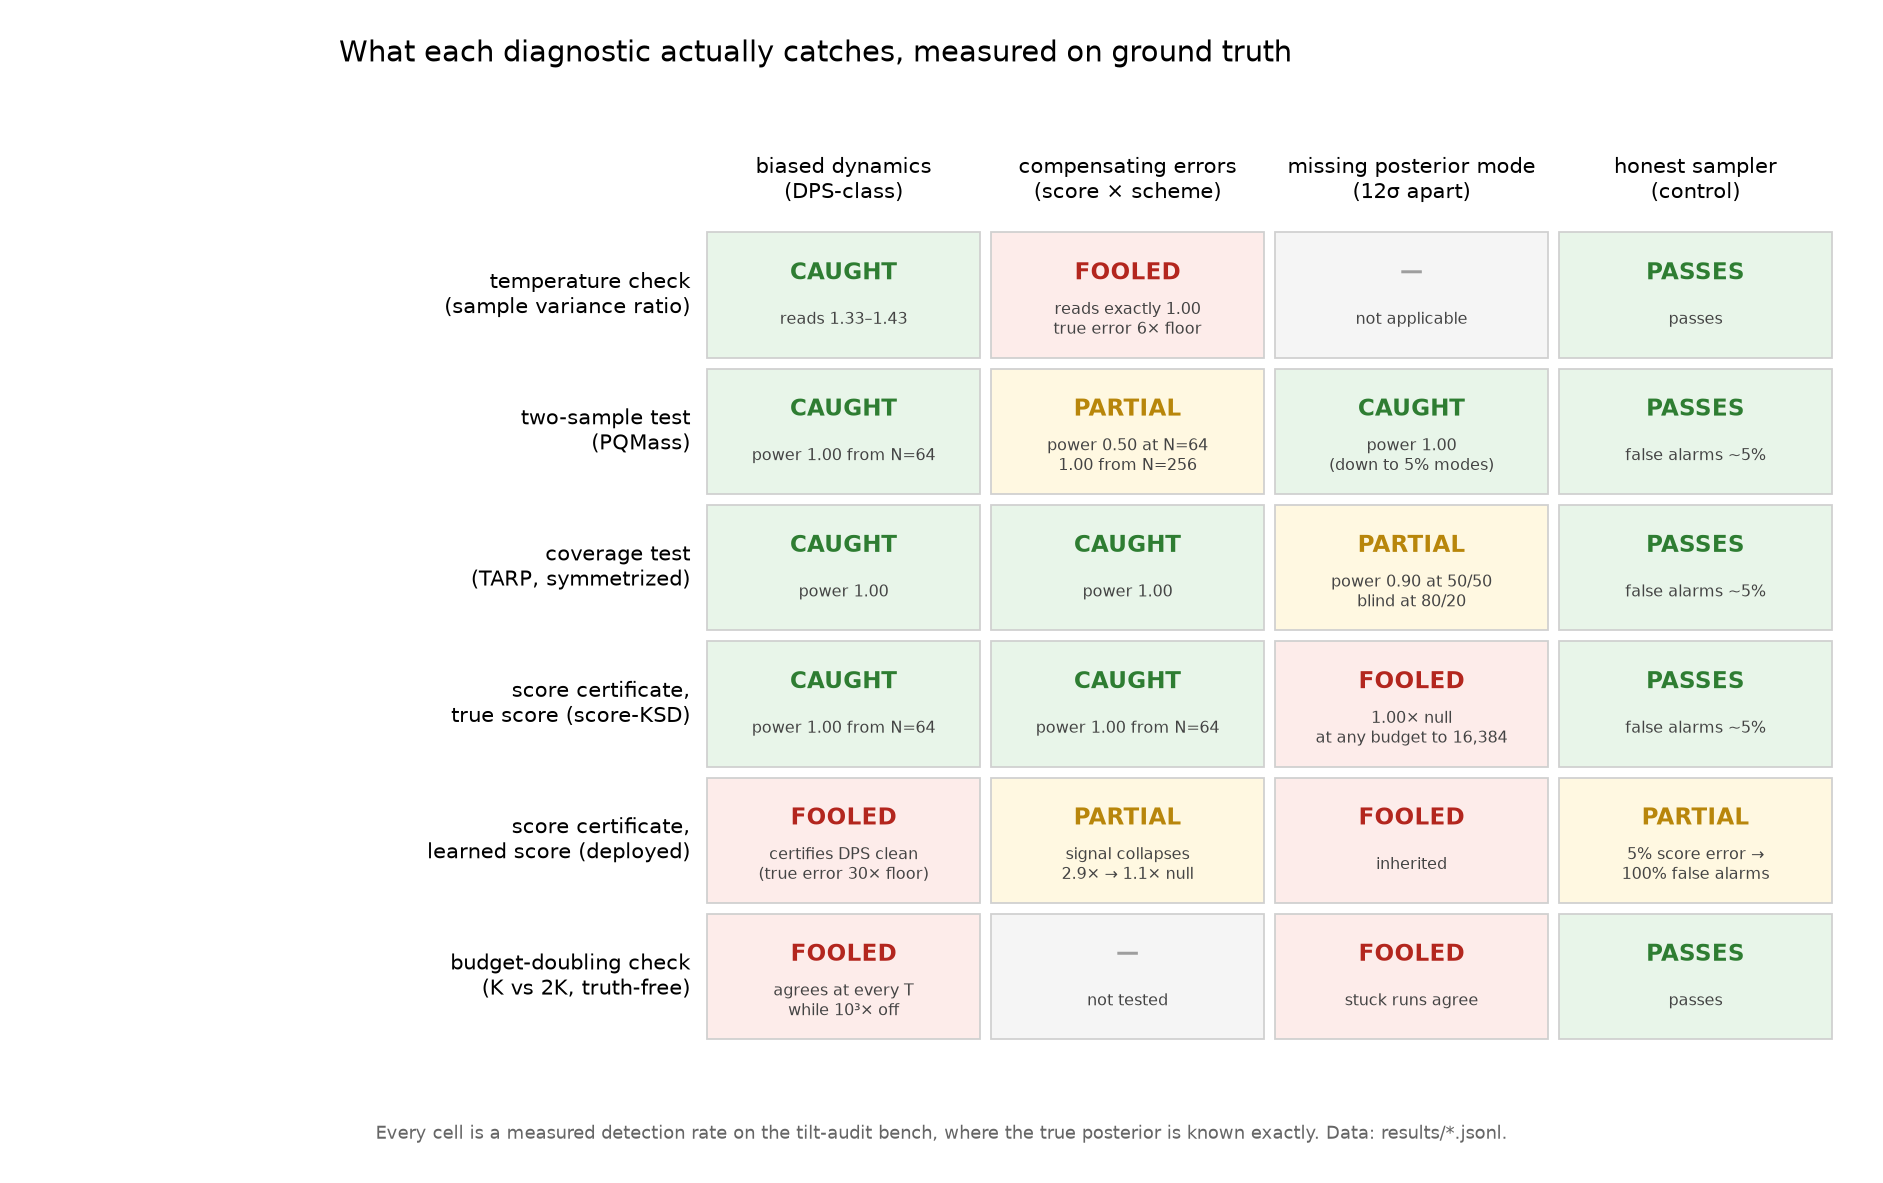

In [5]:
from IPython.display import Image, display
p = ROOT / "figures" / "fig_envelope.png"
if p.exists():
    display(Image(str(p), width=950))